In [1]:
import sys
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torchcodec.decoders import AudioDecoder

sys.path.append("/workspaces/super-duper-dollop/src")
from models.VoiceResNet import VoiceResNet
from data.speaker_dataset import mel_filters

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAMPLE_RATE = 16000
MAX_LENGTH  = 5       
HOP_LENGTH  = 160
N_FFT       = 400
N_MELS      = 80
WIN_SAMPLES = MAX_LENGTH * SAMPLE_RATE   
HOP_SAMPLES = WIN_SAMPLES // 2          
BEFORE_OPERATION = {"1", "3", "31"}

print(f"Device: {DEVICE}")

Device: cuda


In [2]:
def compute_logmel(signal: torch.Tensor, device: torch.device) -> torch.Tensor:

    window = torch.hann_window(N_FFT, device=device)
    stft = torch.stft(
        signal.to(device),
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        window=window,
        return_complex=True,
    )
    magnitudes = stft[..., :-1].abs() ** 2        
    filters = mel_filters(device, N_MELS)
    mel_spec = filters @ magnitudes                  # [1, N_MELS, T_frames]
    log_spec = torch.clamp(mel_spec, min=1e-10).log10()
    log_spec = torch.maximum(log_spec, log_spec.max() - 8.0)
    log_spec = (log_spec + 4.0) / 4.0
    return log_spec                                  # [1, N_MELS, T_frames]


def load_audio_windows(path: Path) -> tuple[list[torch.Tensor], float]:

    dec = AudioDecoder(str(path), sample_rate=SAMPLE_RATE, num_channels=1)
    signal = dec.get_all_samples().data    # [1, T]
    rms_val = float(signal.pow(2).mean().sqrt())

    T = signal.shape[1]
    windows = []
    start = 0
    while start + WIN_SAMPLES <= T:
        windows.append(signal[:, start : start + WIN_SAMPLES])
        start += HOP_SAMPLES

    if not windows:
        pad = WIN_SAMPLES - T
        windows.append(torch.cat([signal, torch.zeros(1, pad)], dim=1))

    logmels = [compute_logmel(w, DEVICE) for w in windows]
    return logmels, rms_val

In [3]:
model = VoiceResNet(dropout=0.3).to(DEVICE)
ckpt = torch.load(
    "/workspaces/super-duper-dollop/best_voiceresnet.pt",
    map_location=DEVICE,
    weights_only=True,
)
model.load_state_dict(ckpt)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"VoiceResNet loaded | {n_params:,} parameters")

VoiceResNet loaded | 711,457 parameters


In [ ]:
data_dir = Path("/workspaces/super-duper-dollop/data/test_sounds2")

results = []

with torch.no_grad():
    for path in sorted(data_dir.glob("*.wav")):
        num_str = path.stem.split("_")[0]
        true_label = 0 if num_str in BEFORE_OPERATION else 1

        logmels, rms_val = load_audio_windows(path)
        window_probs = []
        for lm in logmels:
            x = lm.unsqueeze(0).to(DEVICE)    # [1, 1, N_MELS, T]
            logit = model(x)                   # [1, 1]
            prob = torch.sigmoid(logit).item()
            window_probs.append(prob)

        mean_prob = float(np.mean(window_probs))
        pred_label = int(mean_prob > 0.5)
        correct = pred_label == true_label

        results.append({
            "file":       path.name,
            "true_label": true_label,
            "pred_label": pred_label,
            "prob":       mean_prob,
            "rms":        rms_val,
            "correct":    correct,
            "n_windows":  len(logmels),
        })

In [5]:
label_str = {0: "до", 1: "после"}
n_correct = sum(r["correct"] for r in results)

print(f"{'Файл':<30} {'Истина':>7} {'Прогноз':>8} {'Prob':>6} {'RMS':>6} {'Окна':>5} {'✓':>3}")
print("-" * 75)
for r in results:
    mark = "✓" if r["correct"] else "✗"
    print(
        f"{r['file']:<30} {label_str[r['true_label']]:>7} "
        f"{label_str[r['pred_label']]:>8} {r['prob']:>6.3f} "
        f"{r['rms']:>6.4f} {r['n_windows']:>5} {mark:>3}"
    )
print("-" * 75)
print(f"Accuracy: {n_correct}/{len(results)} = {n_correct/len(results):.1%}")

Файл                            Истина  Прогноз   Prob    RMS  Окна   ✓
---------------------------------------------------------------------------
generated05.wav                  после    после  1.000 0.0376     1   ✓
generated10.wav                  после    после  0.994 0.0336     1   ✓
generated15.wav                  после       до  0.018 0.0323     1   ✗
generated20.wav                  после    после  0.616 0.0290     1   ✓
generated25.wav                  после       до  0.130 0.0229     1   ✗
generated30.wav                  после    после  0.999 0.0209     1   ✓
---------------------------------------------------------------------------
Accuracy: 4/6 = 66.7%


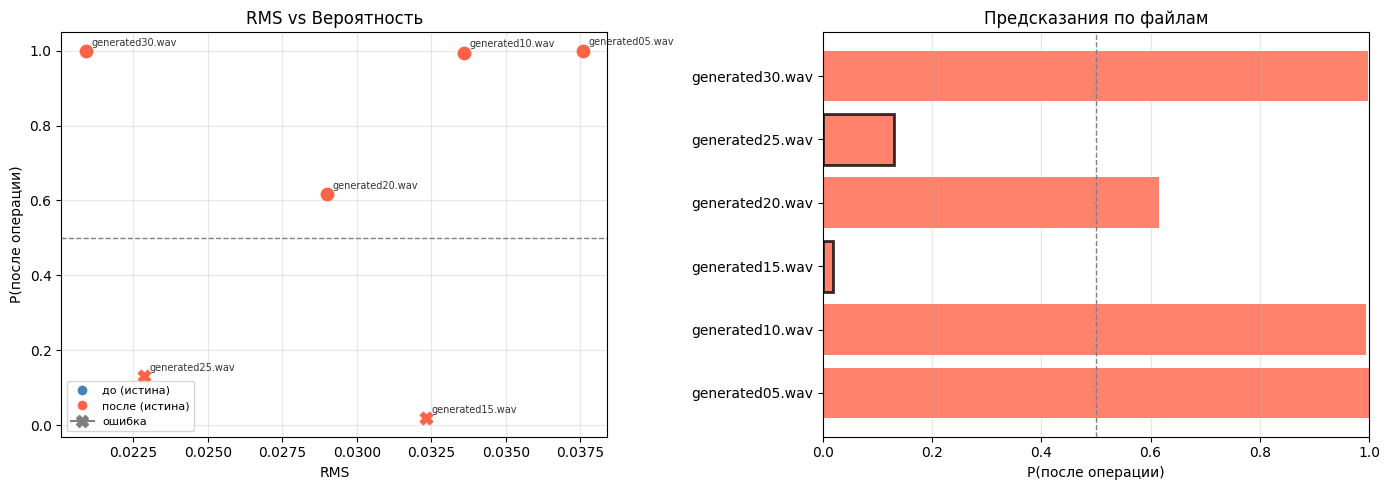

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = ["steelblue" if r["true_label"] == 0 else "tomato" for r in results]
markers = ["o" if r["correct"] else "X" for r in results]

for r, c, m in zip(results, colors, markers):
    ax.scatter(r["rms"], r["prob"], c=c, marker=m, s=80, zorder=3)
    ax.annotate(r["file"], (r["rms"], r["prob"]), xytext=(4, 4),
                textcoords="offset points", fontsize=7, alpha=0.8)

ax.axhline(0.5, linestyle="--", color="gray", linewidth=1)
ax.set_xlabel("RMS")
ax.set_ylabel("P(после операции)")
ax.set_title("RMS vs Вероятность")
ax.legend(
    handles=[
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", label="до (истина)", markersize=8),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="tomato",    label="после (истина)", markersize=8),
        plt.Line2D([0], [0], marker="X", color="gray", label="ошибка", markersize=8),
    ], fontsize=8
)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
files = [r["file"] for r in results]
probs = [r["prob"] for r in results]
bar_colors = ["steelblue" if r["true_label"] == 0 else "tomato" for r in results]
bars = ax2.barh(files, probs, color=bar_colors, alpha=0.8)
ax2.axvline(0.5, linestyle="--", color="gray", linewidth=1)
ax2.set_xlabel("P(после операции)")
ax2.set_title("Предсказания по файлам")
ax2.set_xlim(0, 1)
for bar, r in zip(bars, results):
    if not r["correct"]:
        bar.set_edgecolor("black")
        bar.set_linewidth(2)
ax2.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()